# HR ANALYTICS ATTRITION

## 🎯 Project Objective

The objective of this project is to build an end-to-end Machine Learning model that predicts employee attrition using the IBM HR Analytics dataset.

To achieve this, we will:

- Understand the business problem and its impact.
- Perform Exploratory Data Analysis (EDA) to identify important patterns and factors influencing employee attrition.
- Preprocess the data using appropriate feature engineering techniques.
- Train and compare multiple machine learning models.
- Evaluate model performance using suitable classification metrics.
- Provide business insights and recommendations that can help HR reduce employee attrition.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    precision_score,
    f1_score,
    recall_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE


# Load Dataset

In [3]:
df = pd.read_csv("../data/IBM HR Analytics Employee Attrition & Performance.csv")

# Data Understanding

## Here we seen top 5 rows of data set


In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## How many rows and columns

In [5]:
df.shape

(1470, 35)

## Data types and null count

In [6]:
df.info(34)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Checked duplicated column

In [7]:
df.duplicated().sum()

np.int64(0)

## Here we seen the overall mean and all data analysis

In [8]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [9]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# 📊 Exploratory Data Analysis (EDA)

## How Many Departments 

In [11]:
df["Department"].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

In [12]:
df["Department"].value_counts()


Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [13]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [14]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## Checked Departments with highest Attrition rate

In [15]:
pd.crosstab(df["Department"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


### Observation:

-> Sales department has the highest attrition rate (20.6%), which may be related to higher work pressure, frequent customer interactions, and higher overtime observed in previous analyses.

## Does Overtime affect Attrition

In [16]:
pd.crosstab(df["OverTime"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


### Observation:

-> Employees who work overtime have an attrition rate of approximately 30.5%, compared to only 10.4% for employees who do not work overtime. This indicates that overtime is strongly associated with employee attrition.

In [17]:
df["OverTime"].value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

## Does Gender affect Attrition

In [18]:
pd.crosstab(df["Gender"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


### Observation:

-> Gender shows a minor difference in attrition rate. Male employees has a slightlyy highes attrition rate (17%) where as Female employees has about (17.7%) suggesting gender is not a high predictor for attrition 

## Does Monthly Salary Affect Attrition

<Axes: xlabel='MonthlyIncome', ylabel='Attrition'>

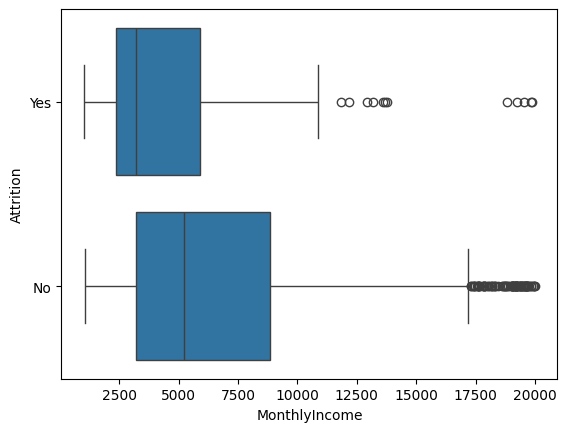

In [19]:
sns.boxplot(x="MonthlyIncome",y="Attrition",data=df)

### Observation:

-> Employees with lower monthly income appear to have a higher attrition rate. However, salary alone may not be the only reason for attrition, as factors such as work-life balance, job satisfaction, and environment satisfaction may also contribute to an employee's decision to leave.

## Does Distance from Home affect Attrition

<Axes: xlabel='DistanceFromHome', ylabel='Attrition'>

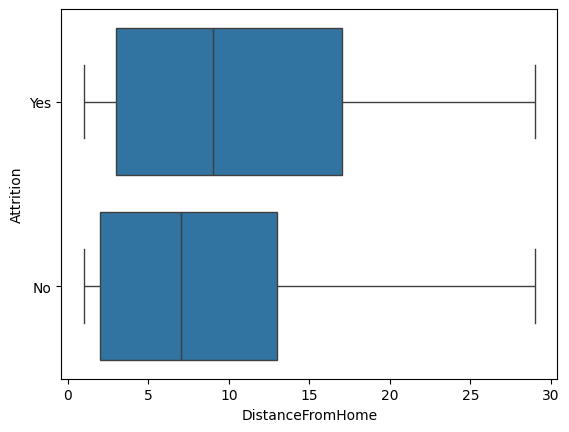

In [20]:
sns.boxplot(x="DistanceFromHome",y="Attrition",data=df)


### Observation:

-> Employees who have a slightly higher median distance from home appear to leave the company more often than employees who stayed. However, the distributions overlap significantly, suggesting that DistanceFromHome alone is not a strong factor influencing attrition.


<Axes: xlabel='DistanceFromHome', ylabel='Count'>

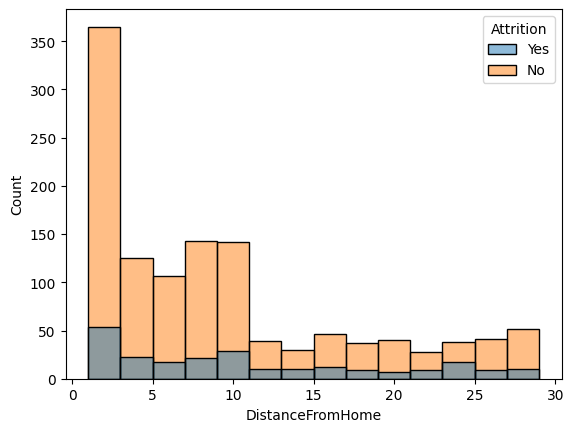

In [21]:
sns.histplot(data=df,x="DistanceFromHome",hue="Attrition",multiple="layer")

## Does Age affects Attrition

<Axes: xlabel='Age', ylabel='Attrition'>

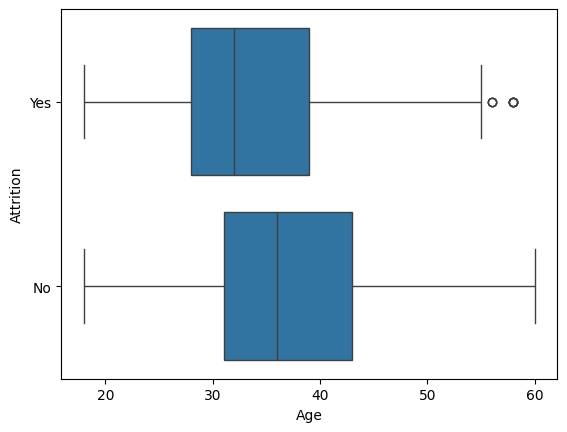

In [22]:
sns.boxplot(x="Age",y="Attrition",data=df)


In [23]:
df.groupby("Attrition")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,37.561233,8.88836,18.0,31.0,36.0,43.0,60.0
Yes,237.0,33.607595,9.68935,18.0,28.0,32.0,39.0,58.0


### Observation:

-> Employees who left the company are generally younger than those who stayed. The median age of employees with attrition is 32 years, compared to 36 years for employees who stayed. This suggests a weak negative relationship between age and attrition, indicating that younger employees are slightly more likely to leave the company.

## Does Jobsatisfaction affects Attrition

In [24]:
df["JobSatisfaction"].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [25]:
pd.crosstab(df["JobSatisfaction"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


### Observation:

-> Employees with the lowest job satisfaction (JobSatisfaction = 1) have the highest attrition rate (22.8%). As job satisfaction increases, the attrition rate gradually decreases, suggesting that higher job satisfaction is associated with lower employee attrition.

<Axes: xlabel='JobSatisfaction', ylabel='count'>

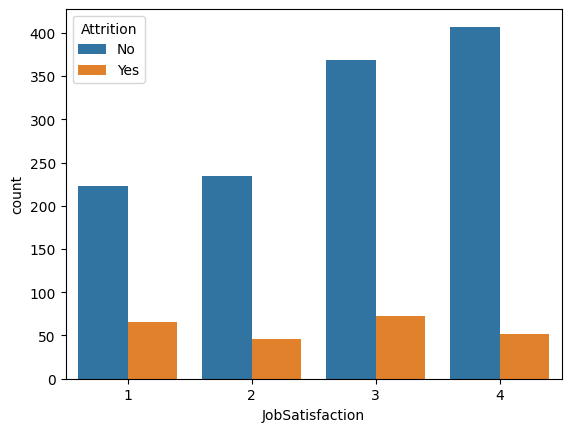

In [26]:
sns.countplot(x="JobSatisfaction",hue="Attrition",data=df)


In [27]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

## Does WorkLifeBalance affects Attrition

In [28]:
pd.crosstab(df["WorkLifeBalance"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


### Observation:

-> Employees with the lowest WorkLifeBalance (Level 1) have the highest attrition rate (31.2%). Overall, attrition tends to decrease as work-life balance improves, although Level 4 shows a slight increase compared to Level 3. This suggests that poorer work-life balance is associated with higher employee attrition. 

## Does YearsAtCompany affects Attrition

<Axes: xlabel='YearsAtCompany', ylabel='Attrition'>

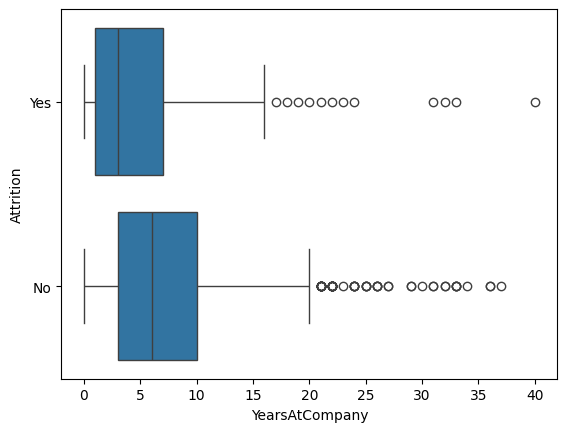

In [29]:
sns.boxplot(x="YearsAtCompany",y="Attrition",data=df)

## Does JobInvolvement affects Attrition

In [30]:
pd.crosstab(df["JobInvolvement"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
JobInvolvement,,
1,66.265060,33.734940
2,81.066667,18.933333
3,85.599078,14.400922
4,90.972222,9.027778


## Does EnvironmentSatisfaction affects Attrition

In [31]:
pd.crosstab(df["EnvironmentSatisfaction"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


## Does overtime affects ppl of different departments

In [32]:
pd.crosstab([df["Department"],df["OverTime"]],df["Attrition"],normalize="index")*100 

Attrition                               No        Yes
Department             OverTime                      
Human Resources        No        84.782609  15.217391
                       Yes       70.588235  29.411765
Research & Development No        91.449275   8.550725
                       Yes       72.693727  27.306273
Sales                  No        86.163522  13.836478
                       Yes       62.500000  37.500000

## Who tends to leave more Males or Females in context to JobSatisfaction

In [33]:
pd.crosstab([df["JobSatisfaction"],df["Gender"]],df["Attrition"],normalize="index")*100 


Attrition                      No        Yes
JobSatisfaction Gender                      
1               Female  82.352941  17.647059
                Male    73.529412  26.470588
2               Female  79.661017  20.338983
                Male    86.419753  13.580247
3               Female  85.635359  14.364641
                Male    81.992337  18.007663
4               Female  90.588235   9.411765
                Male    87.543253  12.456747

## Which JobRole leads to highest attrition

In [34]:
df["JobRole"].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [35]:
pd.crosstab(df["JobRole"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


## Does MaritalStatus affect attrition

In [36]:
pd.crosstab(df["MaritalStatus"],df["Attrition"],normalize="index")*100

Attrition,No,Yes
MaritalStatus,,
Divorced,89.908257,10.091743
Married,87.518574,12.481426
Single,74.468085,25.531915


## Which EducationField shows up the highest attriton rate

In [37]:
pd.crosstab(df["EducationField"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
EducationField,,
Human Resources,74.074074,25.925926
Life Sciences,85.313531,14.686469
Marketing,77.987421,22.012579
Medical,86.422414,13.577586
Other,86.585366,13.414634
Technical Degree,75.757576,24.242424


## Does BusinessTravel affects attrition

In [38]:
pd.crosstab(df["BusinessTravel"],df["Attrition"],normalize="index")*100


Attrition,No,Yes
BusinessTravel,,
Non-Travel,92.000000,8.000000
Travel_Frequently,75.090253,24.909747
Travel_Rarely,85.043145,14.956855


# 📊 Summary of Exploratory Data Analysis

- Employees working overtime exhibit significantly higher attrition rates.
- Sales Representatives have the highest attrition among all job roles.
- Employees with lower job satisfaction are more likely to leave.
- Poor work-life balance is associated with increased attrition.
- Lower monthly income appears to be linked with higher attrition.
- Frequent business travelers tend to leave more often.
- Single employees have higher attrition than married or divorced employees.
- Employees with shorter tenure are more likely to leave.
- Research & Development has the lowest department-level attrition.
- Distance from home showed no strong relationship with attrition.
- Gender showed only a minor difference in attrition rates.

In [39]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [40]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [41]:
df["DailyRate"].head()

0    1102
1     279
2    1373
3    1392
4     591
Name: DailyRate, dtype: int64

In [42]:
df.drop(["Over18","EmployeeNumber","EmployeeCount"],axis=1,inplace=True)

In [43]:
df.shape

(1470, 32)

In [44]:
X = df.drop("Attrition",axis=1)

In [45]:
y = df["Attrition"]

In [46]:
X.select_dtypes(include="object").columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')

In [47]:
onehot_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus','OverTime','Gender']
scale_cols = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]


In [48]:
preprocessor = ColumnTransformer(transformers=[
    ("onehot",OneHotEncoder(drop="first"),onehot_cols),
    ("scaler",StandardScaler(),scale_cols)
    ],
    remainder="passthrough"
    )

In [49]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [50]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [51]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [52]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [53]:
y_pred = model.predict(X_test)

In [54]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[238,   9],
       [ 31,  16]])

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.88      0.96      0.92       247
         Yes       0.64      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.76      0.65      0.68       294
weighted avg       0.85      0.86      0.85       294



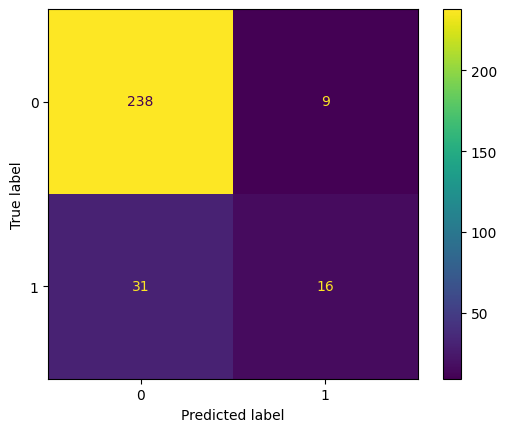

In [56]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [57]:
tree = DecisionTreeClassifier(random_state=42)

In [58]:
tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [59]:
y_pred_tree = tree.predict(X_test)

In [60]:
cm_tree = confusion_matrix(y_test,y_pred_tree)
cm_tree

array([[213,  34],
       [ 30,  17]])

In [61]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

          No       0.88      0.86      0.87       247
         Yes       0.33      0.36      0.35        47

    accuracy                           0.78       294
   macro avg       0.60      0.61      0.61       294
weighted avg       0.79      0.78      0.79       294



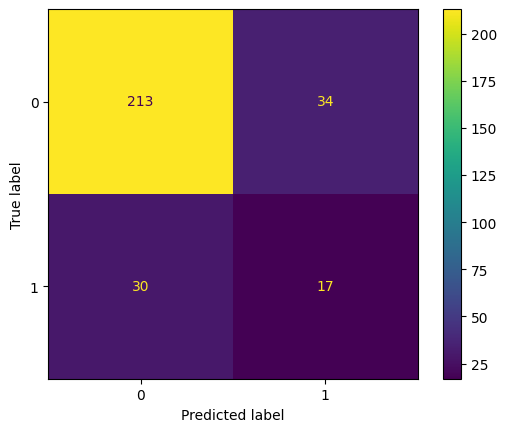

In [62]:
ConfusionMatrixDisplay(confusion_matrix=cm_tree).plot()
plt.show()

In [63]:
tree.score(X_train, y_train)

1.0

In [64]:
tree.score(X_test, y_test)

0.782312925170068

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

recall_scorer = make_scorer(
    recall_score,
    pos_label="Yes"
)
param_grid = {
    "max_depth": [3, 5, 10, 15, 20],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 4, 6, 8]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=5,
    n_jobs=-1,
    error_score="raise"
)

grid.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,make_scorer(r...pos_label=Yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,criterion,'gini'


In [66]:
grid.best_params_

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [67]:
grid.best_score_

np.float64(0.30526315789473685)

In [68]:
best_tree = grid.best_estimator_

In [69]:
y_pred_best = best_tree.predict(X_test)

In [70]:
cm_best_tree = confusion_matrix(y_test,y_pred_best)
cm_best_tree

array([[213,  34],
       [ 31,  16]])

In [71]:
print(classification_report(y_test,y_pred_best))

              precision    recall  f1-score   support

          No       0.87      0.86      0.87       247
         Yes       0.32      0.34      0.33        47

    accuracy                           0.78       294
   macro avg       0.60      0.60      0.60       294
weighted avg       0.78      0.78      0.78       294



In [72]:
rf = RandomForestClassifier()

In [73]:
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
rf_pred = rf.predict(X_test)

In [75]:
cm_rf = confusion_matrix(y_test,rf_pred)
cm_rf

array([[241,   6],
       [ 43,   4]])

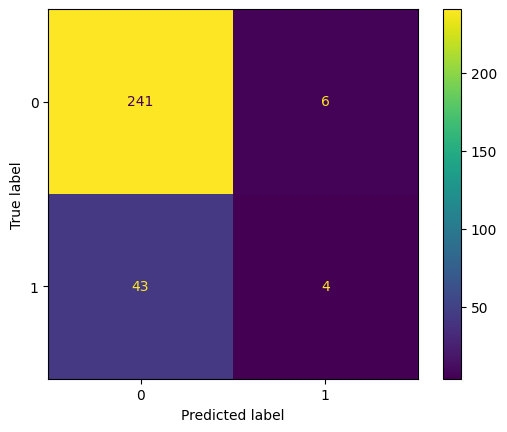

In [76]:
ConfusionMatrixDisplay(confusion_matrix=cm_rf).plot()
plt.show()


In [77]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

          No       0.85      0.98      0.91       247
         Yes       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



In [78]:
best_param_rf = {
    "n_estimators" : [100,200],
    "max_depth" : [5,10,15,20],
    "min_samples_split" : [2,4,6],
    "min_samples_leaf" : [1,2,4],
    "max_features" : ["sqrt","log2"]
}

In [79]:
recall_scorer = make_scorer(recall_score,pos_label="Yes")

In [80]:
grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=best_param_rf,
                       scoring=recall_scorer,
                       cv=5,
                       n_jobs=-1
                       )

In [81]:
grid_rf.fit(X_train,y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,scoring,make_scorer(r...pos_label=Yes)
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [82]:
grid_rf_pred = grid_rf.predict(X_test)

In [83]:
grid_rf_cm = confusion_matrix(y_test,grid_rf_pred)
grid_rf_cm

array([[241,   6],
       [ 43,   4]])

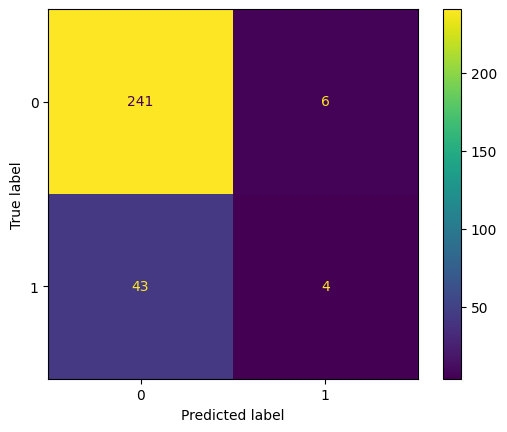

In [84]:
ConfusionMatrixDisplay(confusion_matrix=grid_rf_cm).plot()
plt.show()


In [85]:
print(classification_report(y_test,grid_rf_pred))

              precision    recall  f1-score   support

          No       0.85      0.98      0.91       247
         Yes       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



In [86]:
from xgboost import XGBClassifier

In [87]:
xgb = XGBClassifier()

In [88]:
y_train = y_train.map({
    "No" : 0,
    "Yes" : 1
})

y_test = y_test.map({
    "No" : 0,
    "Yes" : 1
})

In [89]:
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [90]:
xgb_pred = xgb.predict(X_test)

In [91]:
xgb_cm = confusion_matrix(y_test,xgb_pred)
xgb_cm

array([[242,   5],
       [ 36,  11]])

In [92]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.3]
}

In [93]:
grid_xg = GridSearchCV(estimator=XGBClassifier(),
                       cv=5,
                       scoring="recall",
                       param_grid=param_grid_xgb,
                       n_jobs=-1)

In [94]:
grid_xg.fit(X_train,y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [95]:
grid_xg_pred = grid_xg.predict(X_test)

In [96]:
grid_xg_pred_cm = confusion_matrix(y_test,grid_xg_pred)
grid_xg_pred_cm

array([[243,   4],
       [ 32,  15]])

In [97]:
print(classification_report(y_test,grid_xg_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.79      0.32      0.45        47

    accuracy                           0.88       294
   macro avg       0.84      0.65      0.69       294
weighted avg       0.87      0.88      0.85       294



In [98]:
grid_xg.best_params_

{'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 500}

In [99]:
grid_xg.best_score_

np.float64(0.37894736842105264)

In [100]:
grid_xg.best_estimator_

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [101]:
lr1 = LogisticRegression(max_iter=1000)

In [102]:
rfe = RFE(estimator=lr1,
          n_features_to_select = 15)

In [103]:
rfe.fit(X_train,y_train)

,estimator,LogisticRegre...max_iter=1000)
,n_features_to_select,15
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [104]:
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

In [105]:
lr1.fit(X_train_rfe,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [106]:
lr1_pred = lr1.predict(X_test_rfe)

In [107]:
lr1_cm = confusion_matrix(y_test,lr1_pred)
lr1_cm

array([[238,   9],
       [ 36,  11]])

In [108]:
print(classification_report(y_test,lr1_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.71      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



In [109]:
from imblearn.over_sampling import SMOTE

In [110]:
smote = SMOTE(random_state=42)

In [111]:
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [112]:
lr_smote = LogisticRegression(max_iter=1000)

In [113]:
lr_smote.fit(X_train_smote,y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [114]:
lr_smote_pred = lr_smote.predict(X_test)

In [115]:
lr_smote_cm = confusion_matrix(y_test,lr_smote_pred)
lr_smote_cm

array([[201,  46],
       [ 17,  30]])

In [116]:
print(classification_report(y_test,lr_smote_pred))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.39      0.64      0.49        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.80       294



In [117]:
grid_xg_smote = GridSearchCV(estimator=XGBClassifier(),
                       cv=5,
                       scoring="recall",
                       param_grid=param_grid_xgb,
                       n_jobs=-1)

In [118]:
grid_xg_smote.fit(X_train_smote,y_train_smote)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [119]:
grid_xg_smote_pred = grid_xg_smote.predict(X_test)

In [120]:
grid_xg_smote_cm = confusion_matrix(y_test,grid_xg_smote_pred)
grid_xg_smote_cm

array([[234,  13],
       [ 35,  12]])

In [121]:
lr_class_weight = LogisticRegression(max_iter=1000,class_weight="balanced")
lr_class_weight.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [122]:
lr_class_weight_pred = lr_class_weight.predict(X_test)

In [123]:
lr_class_weight_cm = confusion_matrix(y_test,lr_class_weight_pred)
lr_class_weight_cm

array([[191,  56],
       [ 16,  31]])

In [124]:
print(classification_report(y_test,lr_class_weight_pred))

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294



In [125]:
leave_prob = lr_class_weight.predict_proba(X_test)[:,1]

In [126]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

In [127]:
results = []
for t in thresholds:
    y_pred_thresholds = (leave_prob >= t).astype(int)

    accuracy = accuracy_score(y_test,y_pred_thresholds)
    precision = precision_score(y_test,y_pred_thresholds)
    recall = recall_score(y_test,y_pred_thresholds)
    f1 = f1_score(y_test,y_pred_thresholds)

    
    results.append([
        t,
        accuracy,
        precision,
        recall,
        f1
    ])

In [128]:
result_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)
result_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.50,0.755102,0.356322,0.659574,0.462687
1,0.45,0.744898,0.354167,0.723404,0.475524
2,0.40,0.734694,0.355140,0.808511,0.493506
3,0.35,0.683673,0.311475,0.808511,0.449704
4,0.30,0.642857,0.283582,0.808511,0.419890
5,0.25,0.591837,0.258278,0.829787,0.393939


In [129]:
from sklearn.metrics import roc_curve,roc_auc_score

fpr, tpr , thresholds = roc_curve(y_test,leave_prob)
auc = roc_auc_score(y_test,leave_prob)

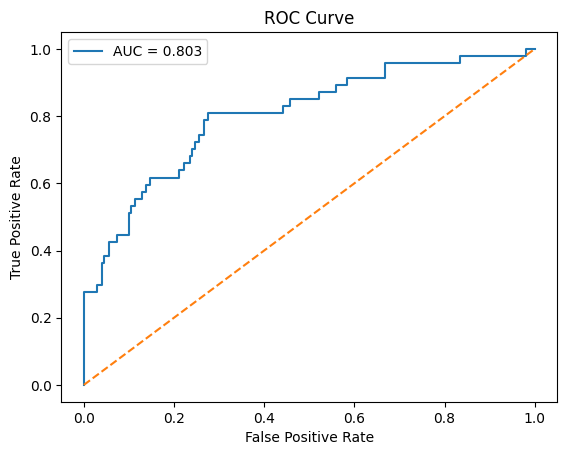

In [130]:
plt.Figure(figsize=(6,6))
plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [131]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    leave_prob
)

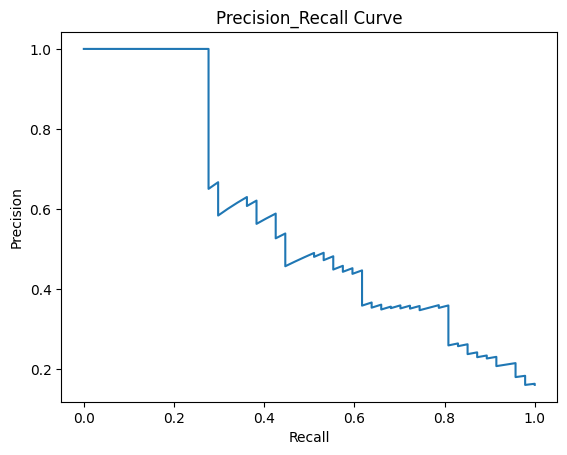

In [132]:
plt.Figure(figsize=(6,6))
plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision_Recall Curve")


plt.show()

In [133]:
# ============================
# Final Model Selection
# ============================

best_model = lr_class_weight
best_threshold = 0.40

## Final Model

After comparing all models and threshold values, the selected production model is:

• Model: Logistic Regression (Class Weight = Balanced)
• Decision Threshold: 0.40

This configuration provides the best balance for the business objective of minimizing False Negatives while maintaining acceptable Precision and F1-score.

In [134]:
coefficients = lr_class_weight.coef_[0]

In [135]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature" : feature_names,
    "Coefficient" : coefficients
})

In [136]:
feature_importance["Importance"] = (feature_importance["Coefficient"].abs())

In [137]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [138]:
top10 = feature_importance.head(10)

<Axes: xlabel='Importance', ylabel='Feature'>

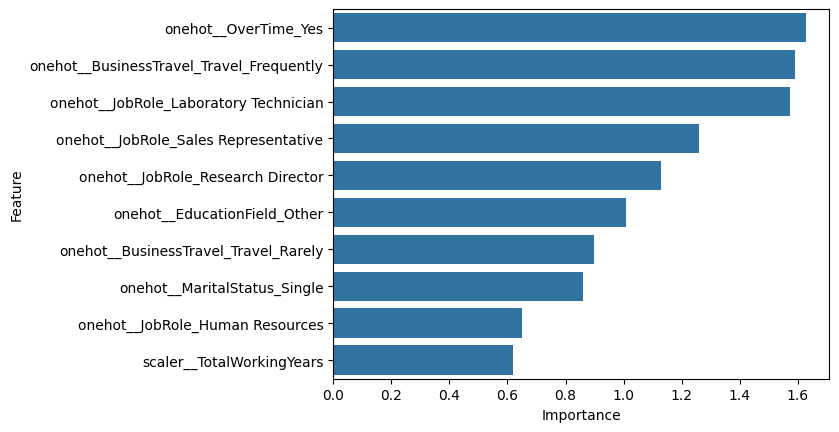

In [139]:
sns.barplot(x="Importance",y="Feature",data=top10)

In [140]:
import shap

In [141]:
explainer = shap.Explainer(best_model,X_train)
shap_values = explainer(X_test)

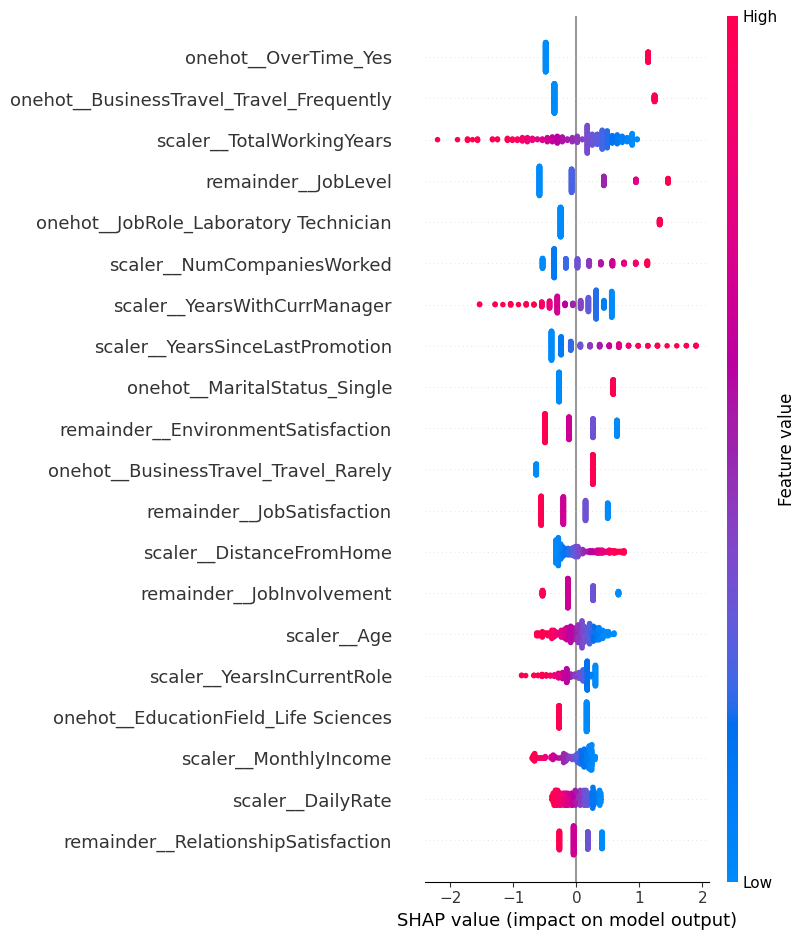

In [142]:
shap.summary_plot(shap_values,X_test,feature_names=feature_names)

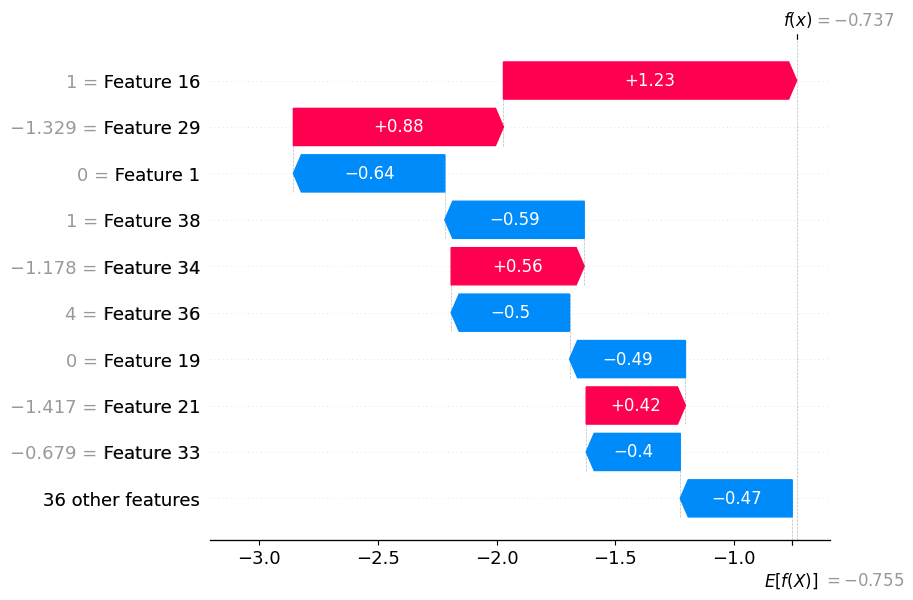

In [143]:
shap.plots.waterfall(shap_values[0])

In [144]:
shap.initjs()
shap.force_plot(shap_values[0])


In [145]:
import joblib

joblib.dump(lr_class_weight,"../models/lr_class_weight.pkl")
joblib.dump(preprocessor,"../models/preprocessor.pkl")
joblib.dump(X_train[:100],"../models/background_data.pkl")

['../models/background_data.pkl']

In [146]:
X.columns

Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')